### Импортируем библиотеки

In [1]:
# Стандартная библиотека
import os
import random
import tarfile
from typing import List, Tuple

# Сторонние библиотеки
import numpy as np
import pandas as pd
import PIL
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

### Загрузим данные и разархивируем их

In [2]:
kaggle = True
dir = ''
if kaggle:
    dir = '/kaggle/input/homework-06/'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
if not (os.path.exists('data') and os.listdir('data')) and kaggle == False:
    os.makedirs('data', exist_ok=True)
    with tarfile.open(dir + 'best_pictures.tar.gz', 'r:gz') as tar:
        tar.extractall(path='data')
        dir = 'data/'
        print(f"Архив 'best_pictures.tar.gz' успешно распакован в папку 'data'.")

#### Загрузим известные нам фильтры

In [4]:
filters = pd.read_csv(dir +'algos.csv', header=None)
f1 = filters.iloc[0, :].to_numpy().reshape(3, 3).astype(np.float32)
f2 = filters.iloc[1, :].to_numpy().reshape(3, 3).astype(np.float32)

f1, f2

(array([[-1. , -0.5,  0. ],
        [-0.5,  0.5,  0.5],
        [ 0. ,  0.5,  1. ]], dtype=float32),
 array([[0.0625, 0.0625, 0.0625],
        [0.0625, 0.0625, 0.0625],
        [0.0625, 0.0625, 0.0625]], dtype=float32))

#### Выгрузим одну рандомную фотку и текст к нему

64 64 [[ 284.484375    316.76171875  308.921875   ...  164.59765625
   119.0546875    18.69140625]
 [ 317.3671875   267.3828125   211.15234375 ...   97.44921875
    44.10546875  -61.37109375]
 [ 309.22265625  210.03515625  124.78125    ...   46.5234375
    -6.82421875 -104.41015625]
 ...
 [ 246.0078125   152.55078125   80.83203125 ...   42.83203125
   -42.0546875  -182.5078125 ]
 [ 173.4140625    67.16796875   -5.73828125 ...  -41.55859375
  -102.84375    -196.49609375]
 [  26.91796875  -88.7421875  -154.3515625  ... -182.91796875
  -197.0390625  -199.08984375]]


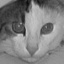

In [5]:
rnd = random.randint(1, 1000)
photo_rnd = PIL.Image.open(dir + f'{rnd}.png')
text_rnd = np.loadtxt(dir +f'{rnd}.txt')
print(len(text_rnd), len(text_rnd[0]), text_rnd)  # размеры матриц
photo_rnd

In [6]:
img_array = np.array(photo_rnd).astype(np.float32)
img_array.shape


(64, 64)

#### Т.к. размеры фото и размеры выходного слоя одинаковы *h: 64=64, w: 64=64*.
##### Из этого следует, что там присутствует паддинг, при каждом слое (либо 0, либо продление такими же значениями)

In [7]:
conv1 = convolve2d(img_array, f1, mode='same', boundary='fill', fillvalue=0)
conv2 = convolve2d(conv1, f2, mode='same', boundary='fill', fillvalue=0)

conv2

array([[-30.4375 , -35.5625 , -15.03125, ...,  -7.15625,  10.59375,
         12.59375],
       [-35.78125, -35.3125 ,   1.1875 , ...,  -0.3125 ,  26.65625,
         26.375  ],
       [-15.25   ,   1.1875 ,  49.21875, ...,  23.375  ,  51.5    ,
         43.40625],
       ...,
       [-13.8125 ,  -1.25   ,  37.78125, ...,  41.46875,  83.0625 ,
         69.25   ],
       [ 12.5625 ,  38.53125,  77.9375 , ...,  82.59375, 114.96875,
         87.46875],
       [ 17.4375 ,  39.25   ,  65.4375 , ...,  68.65625,  87.15625,
         64.3125 ]], dtype=float32)

#### Напишем класс для наших данных

In [8]:
class ImageTxtDataset(Dataset):
    def __init__(self, data_dir, num_files=1000, transform=None):
        """
        Args:
            data_dir (str): Путь к директории, содержащей файлы 1.png, 1.txt, ..., 1000.png, 1000.txt.
            num_files (int): Количество пар файлов.
            transform (callable, optional): Опциональные трансформации для изображений/таргетов.
        """
        self.data_dir = data_dir
        self.num_files = num_files
        self.transform = transform
        self.filenames = [str(i) for i in range(1, num_files + 1)]

    def __len__(self):
        return self.num_files

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        base_filename = self.filenames[idx]
        img_path = os.path.join(self.data_dir, f"{base_filename}.png")
        txt_path = os.path.join(self.data_dir, f"{base_filename}.txt")

        image = PIL.Image.open(img_path)
        image_np = np.array(image).astype(np.float32)

        target_np = np.loadtxt(txt_path).astype(np.float32)

        image_tensor = torch.from_numpy(image_np).unsqueeze(0)
        target_tensor = torch.from_numpy(target_np).unsqueeze(0)

        sample = {'image': image_tensor, 'target': target_tensor}

        if self.transform:
            sample = self.transform(sample)

        return sample['image'], sample['target']

#### Функция для визуализации лоссов

In [9]:
def plot_losses(
    losses_data: List[Tuple[str, List[float]]],
    title: str = "Динамика потерь (MSE) при обучении"
) -> None:
    """
    Рисует графики истории потерь для одного или нескольких запусков обучения.

    Args:
        losses_data: Список кортежей. Каждый кортеж содержит:
                     - строку-метку (например, описание порядка)
                     - список значений потерь по эпохам для этого запуска.
                     Пример: [('Порядок A', [10.5, 8.2, ...]), ('Порядок B', [15.1, 11.0, ...])]
        title: Заголовок графика.
    """

    plt.figure(figsize=(12, 6))

    for label, loss_history in losses_data:
        if loss_history:
            epochs = range(1, len(loss_history) + 1)
            plt.plot(epochs, loss_history, label=label, marker='.')

    plt.xlabel("Эпоха")
    plt.ylabel("Средние потери (MSE)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Функция для обучения

In [10]:
def train_fx_for_order_batched(
    dataloader: DataLoader,
    f1_np: np.ndarray,
    f2_np: np.ndarray,
    order: tuple[str, str, str],
    num_epochs: int = 50,
    learning_rate: float = 0.001,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> tuple[np.ndarray, float, list[float]]:
    """
    Обучает неизвестный фильтр FX для заданного порядка, используя DataLoader.

    Args:
        dataloader: DataLoader с батчами изображений и таргетов.
        f1_np: Известный фильтр F1 (NumPy array, 3x3).
        f2_np: Известный фильтр F2 (NumPy array, 3x3).
        order: Кортеж строк, указывающий порядок ('f1', 'f2', 'fx').
        num_epochs: Количество эпох обучения.
        learning_rate: Скорость обучения.
        device: Устройство для вычислений (torch.device).

    Returns:
        Кортеж:
            - Обученный фильтр FX (NumPy array, 3x3).
            - Финальное среднее значение потерь за последнюю эпоху.
            - Список средних потерь для каждой эпохи обучения.
    """

    f1_tensor = torch.from_numpy(f1_np.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device).detach()
    f2_tensor = torch.from_numpy(f2_np.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device).detach()
    known_filters = {'f1': f1_tensor, 'f2': f2_tensor}

    fx_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False).to(device)

    optimizer = optim.Adam(fx_layer.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    epoch_losses_history = []

    for epoch in tqdm(range(1, num_epochs+1)):
        epoch_loss = 0.0
        fx_layer.train()

        for batch_input, batch_target in dataloader:
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()

            current_tensor = batch_input
            for filter_key in order:
                if filter_key == 'fx':
                    current_tensor = fx_layer(current_tensor)
                elif filter_key in known_filters:
                    current_tensor = F.conv2d(current_tensor, known_filters[filter_key], padding=1)

            output_tensor = current_tensor
            loss = criterion(output_tensor, batch_target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        epoch_losses_history.append(avg_epoch_loss)

    print(f"Обучение для порядка {order} завершено. Финальные средние потери: {avg_epoch_loss:.6f}")

    fx_trained_np = fx_layer.weight.data.detach().cpu().numpy().squeeze()
    return fx_trained_np, avg_epoch_loss, epoch_losses_history

#### Наши действия
![image.png](https://i.imgur.com/nfxXP6I.png)

#### Теперь посмотрим какие лоссы, у каждого случая

In [11]:
image_dataset = ImageTxtDataset(data_dir=dir)
image_dataloader = DataLoader(image_dataset, batch_size=64, shuffle=True)

In [12]:
all_filters = [('f1', 'f2', 'fx'), 
               ('f1', 'fx', 'f2'),
               ('f2', 'f1', 'fx'),
               ('f2', 'fx', 'f1'),
               ('fx', 'f1', 'f2'),
               ('fx', 'f2', 'f1'),
               ]

all_plot_data = []
trained_filters_results = {}
final_losses = []

for order in all_filters:
    fx_trained_np, avg_loss, loss_history = train_fx_for_order_batched(image_dataloader, 
                                                         f1, 
                                                         f2, 
                                                         order, 
                                                         num_epochs=20,
                                                         learning_rate=1,
                                                         device=device
                                                         )
    trained_filters_results[order] = (fx_trained_np, avg_loss)
    final_losses.append(avg_loss)

    plot_label = f"Порядок {order}"
    all_plot_data.append((plot_label, loss_history))


print("Финальные средние потери для каждого порядка:", final_losses)

  0%|          | 0/20 [00:00<?, ?it/s]

Обучение для порядка ('f1', 'f2', 'fx') завершено. Финальные средние потери: 901.540058


  0%|          | 0/20 [00:00<?, ?it/s]

Обучение для порядка ('f1', 'fx', 'f2') завершено. Финальные средние потери: 924.269104


  0%|          | 0/20 [00:00<?, ?it/s]

...

Обучение для порядка ('f2', 'fx', 'f1') завершено. Финальные средние потери: 0.033203


  0%|          | 0/20 [00:00<?, ?it/s]

Обучение для порядка ('fx', 'f1', 'f2') завершено. Финальные средние потери: 515.720530


  0%|          | 0/20 [00:00<?, ?it/s]

Обучение для порядка ('fx', 'f2', 'f1') завершено. Финальные средние потери: 0.156013
Финальные средние потери для каждого порядка: [901.5400581359863, 924.2691040039062, 43.60635423660278, 0.03320269344840199, 515.7205295562744, 0.15601331926882267]


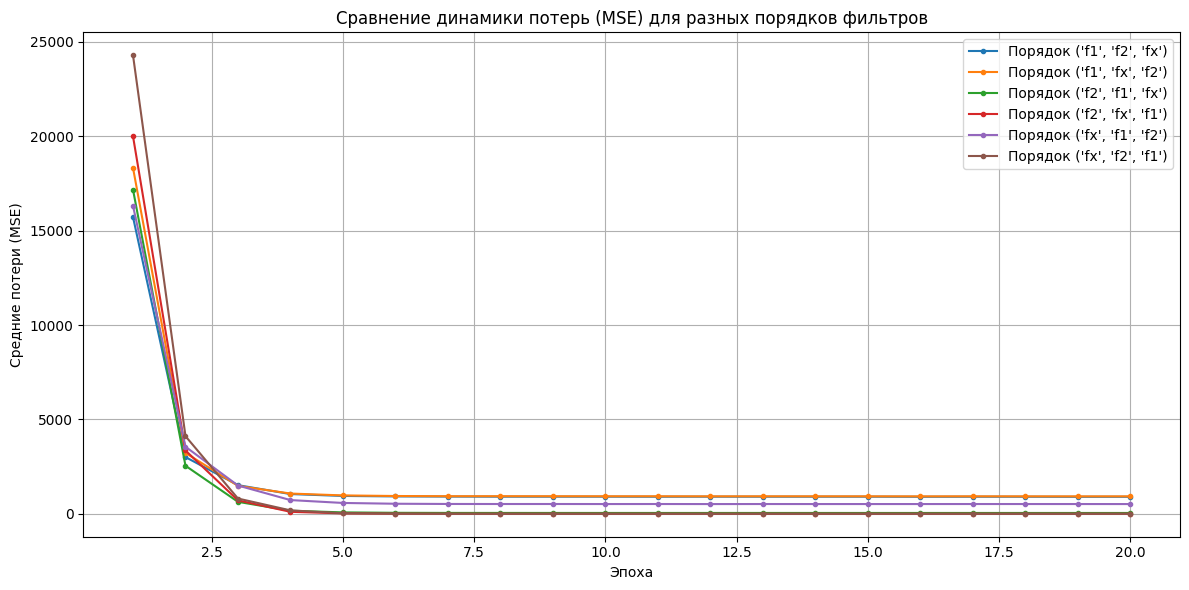

In [13]:
plot_losses(all_plot_data, 
            title="Сравнение динамики потерь (MSE) для разных порядков фильтров",
            )

#### Дообучим поновой наш слой (побольше эпох) и сохраним

In [14]:
all_plot_data = []

fx_trained_np, avg_loss, loss_history = train_fx_for_order_batched(image_dataloader, 
                                                         f1, 
                                                         f2, 
                                                         ('f2', 'fx', 'f1'), 
                                                         num_epochs=300,
                                                         learning_rate=1,
                                                         device=device
                                                         )
trained_filters_results[order] = (fx_trained_np, avg_loss)
final_losses.append(avg_loss)

plot_label = f"Порядок {order}"
all_plot_data.append((plot_label, loss_history[30:]))

  0%|          | 0/300 [00:00<?, ?it/s]

Обучение для порядка ('f2', 'fx', 'f1') завершено. Финальные средние потери: 0.005975


In [15]:
best_order = min(trained_filters_results, key=lambda k: trained_filters_results[k][1])
best_fx_filter, min_loss = trained_filters_results[best_order]

print(f"Найден лучший порядок: {best_order} с минимальной потерей MSE: {min_loss:.6f}")

Найден лучший порядок: ('fx', 'f2', 'f1') с минимальной потерей MSE: 0.005975


In [16]:
final_ordered_filters = [f2, best_fx_filter, f1]
filters_to_save = np.array([f.flatten() for f in final_ordered_filters])
np.savetxt('reconstructed_algos.csv', filters_to_save, delimiter=',', fmt='%.18e')